In [1]:
import kagglehub as kh
import plotly.express as px
import plotly.io as pio

pio.templates.default = 'plotly_white'

In [2]:
df = kh.dataset_load(
  kh.KaggleDatasetAdapter.PANDAS,
  "hopesb/student-depression-dataset",
  "Student Depression Dataset.csv",
)

In [3]:
df.columns

Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='str')

In [4]:
# rename columns by removing space from the names
df.columns = df.columns.str.replace({
    ' ': '', '/': '', 
    'Haveyoueverhadsuicidalthoughts?': 'HadSuicidalThoughts'
})

In [5]:
df.columns

Index(['id', 'Gender', 'Age', 'City', 'Profession', 'AcademicPressure',
       'WorkPressure', 'CGPA', 'StudySatisfaction', 'JobSatisfaction',
       'SleepDuration', 'DietaryHabits', 'Degree', 'HadSuicidalThoughts',
       'WorkStudyHours', 'FinancialStress', 'FamilyHistoryofMentalIllness',
       'Depression'],
      dtype='str')

In [6]:
df

,id,Gender,Age,City,Profession,AcademicPressure,WorkPressure,CGPA,StudySatisfaction,JobSatisfaction,SleepDuration,DietaryHabits,Degree,HadSuicidalThoughts,WorkStudyHours,FinancialStress,FamilyHistoryofMentalIllness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,140685,Female,27.0,Surat,Student,5.0,0.0,5.75,5.0,0.0,5-6 hours,Unhealthy,Class 12,Yes,7.0,1.0,Yes,0
27897,140686,Male,27.0,Ludhiana,Student,2.0,0.0,9.40,3.0,0.0,Less than 5 hours,Healthy,MSc,No,0.0,3.0,Yes,0
27898,140689,Male,31.0,Faridabad,Student,3.0,0.0,6.61,4.0,0.0,5-6 hours,Unhealthy,MD,No,12.0,2.0,No,0
27899,140690,Female,18.0,Ludhiana,Student,5.0,0.0,6.88,2.0,0.0,Less than 5 hours,Healthy,Class 12,Yes,10.0,5.0,No,1


In [7]:
df.describe()

,id,Age,AcademicPressure,WorkPressure,CGPA,StudySatisfaction,JobSatisfaction,WorkStudyHours,FinancialStress,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27898.000000,27901.000000
mean,70442.149421,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,3.139867,0.585499
std,40641.175216,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,1.437347,0.492645
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,35039.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,2.000000,0.000000
50%,70684.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,3.000000,1.000000
75%,105818.000000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,4.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,5.000000,1.000000


In [8]:
df.isnull().any()

id                              False
Gender                          False
Age                             False
City                            False
Profession                      False
AcademicPressure                False
WorkPressure                    False
CGPA                            False
StudySatisfaction               False
JobSatisfaction                 False
SleepDuration                   False
DietaryHabits                   False
Degree                          False
HadSuicidalThoughts             False
WorkStudyHours                  False
FinancialStress                  True
FamilyHistoryofMentalIllness    False
Depression                      False
dtype: bool

# Data eda

## Gender

Verdict: we have only two genders, convert to 0/1 value

In [9]:
df.Gender.value_counts()

Gender
Male      15547
Female    12354
Name: count, dtype: int64

## Age

Verdict: drop the rows with age larger than 34.5

In [10]:
df.Age.value_counts().sort_index()

Age
18.0    1587
19.0    1560
20.0    2237
21.0    1726
22.0    1160
23.0    1645
24.0    2258
25.0    1784
26.0    1155
27.0    1462
28.0    2133
29.0    1950
30.0    1145
31.0    1427
32.0    1262
33.0    1893
34.0    1468
35.0      10
36.0       7
37.0       2
38.0       8
39.0       3
41.0       1
42.0       4
43.0       2
44.0       1
46.0       2
48.0       3
49.0       1
51.0       1
54.0       1
56.0       1
58.0       1
59.0       1
Name: count, dtype: int64

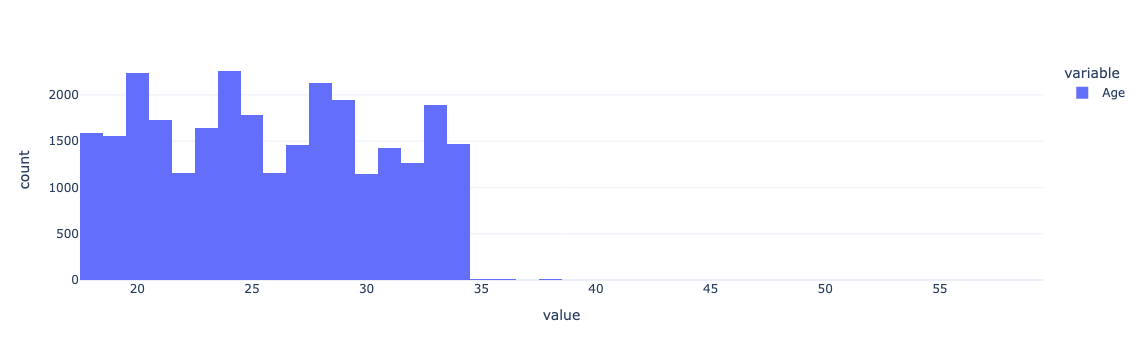

In [11]:
px.histogram(df.Age)

In [12]:
(df.Age > 34).sum()

np.int64(49)

In [13]:
df[df.Age > 34]

,id,Gender,Age,City,Profession,AcademicPressure,WorkPressure,CGPA,StudySatisfaction,JobSatisfaction,SleepDuration,DietaryHabits,Degree,HadSuicidalThoughts,WorkStudyHours,FinancialStress,FamilyHistoryofMentalIllness,Depression
201,978,Female,39.0,Kalyan,Student,5.0,0.0,6.51,4.0,0.0,7-8 hours,Moderate,M.Tech,Yes,7.0,2.0,No,1
307,1493,Female,35.0,Meerut,Student,5.0,0.0,5.32,2.0,0.0,7-8 hours,Moderate,PhD,No,3.0,4.0,Yes,0
1076,5569,Female,42.0,Rajkot,Student,2.0,0.0,9.03,5.0,0.0,More than 8 hours,Moderate,Class 12,Yes,3.0,1.0,Yes,0
1330,6852,Male,36.0,Mumbai,Student,5.0,0.0,7.10,5.0,0.0,Less than 5 hours,Moderate,MSc,Yes,0.0,2.0,Yes,0
2885,14659,Female,36.0,Agra,Student,3.0,0.0,5.90,5.0,0.0,7-8 hours,Healthy,MCA,No,11.0,5.0,Yes,0
2909,14768,Female,58.0,Chennai,Student,4.0,0.0,8.58,1.0,0.0,7-8 hours,Healthy,Class 12,No,4.0,4.0,No,0
3337,16725,Female,39.0,Vadodara,Student,4.0,0.0,5.60,2.0,0.0,Less than 5 hours,Unhealthy,M.Ed,Yes,9.0,5.0,Yes,1
3436,17213,Male,49.0,Nagpur,Student,3.0,0.0,6.47,3.0,0.0,5-6 hours,Moderate,Class 12,Yes,2.0,1.0,Yes,0
4365,21880,Male,38.0,Chennai,Student,0.0,5.0,0.00,0.0,4.0,5-6 hours,Healthy,Class 12,No,2.0,3.0,No,0
4386,22004,Female,51.0,Bhopal,Student,2.0,0.0,8.26,3.0,0.0,Less than 5 hours,Moderate,MBBS,Yes,5.0,5.0,Yes,0


Those old students might be outliers or maybe not.
We'll remove them on the first stage, but might handle differently to improve accuracy later

## City

Verdict: drop the rows with too rare city values, one-hot the rest

In [14]:
df.City.value_counts().sort_index()

City
3.0                      1
Agra                  1094
Ahmedabad              951
Bangalore              767
Bhavna                   2
Bhopal                 934
Chennai                885
City                     2
Delhi                  768
Faridabad              461
Gaurav                   1
Ghaziabad              745
Harsh                    1
Harsha                   2
Hyderabad             1340
Indore                 643
Jaipur                1036
Kalyan                1570
Kanpur                 609
Khaziabad                1
Kibara                   1
Kolkata               1066
Less Delhi               1
Less than 5 Kalyan       1
Lucknow               1155
Ludhiana              1111
M.Com                    1
M.Tech                   1
ME                       1
Meerut                 825
Mihir                    1
Mira                     1
Mumbai                 699
Nagpur                 651
Nalini                   1
Nalyan                   1
Nandini                

Some values look like Degree column

In [15]:
t = df.City.value_counts() <= 2
t[t]

City
Saanvi                True
Bhavna                True
City                  True
Harsha                True
M.Tech                True
Less Delhi            True
3.0                   True
Less than 5 Kalyan    True
Mira                  True
Vaanya                True
Gaurav                True
Harsh                 True
Reyansh               True
Kibara                True
Rashi                 True
ME                    True
M.Com                 True
Nalyan                True
Mihir                 True
Nalini                True
Nandini               True
Khaziabad             True
Name: count, dtype: bool

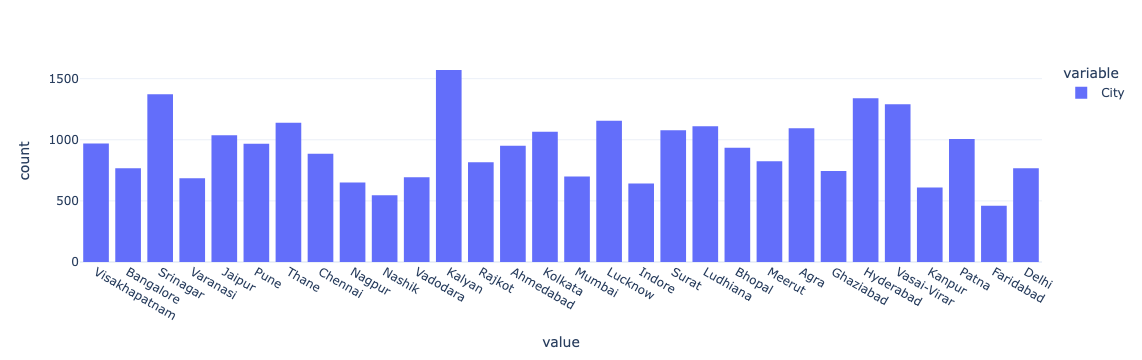

In [16]:
px.histogram(df.City[df.City.isin(t[~t].index)])

Simple solution - remove those rows, can use imputing to keep

## Profession

Verdict: drop the column

In [17]:
df.Profession.value_counts().sort_index()

Profession
Architect                     8
Chef                          2
Civil Engineer                1
Content Writer                2
Digital Marketer              3
Doctor                        2
Educational Consultant        1
Entrepreneur                  1
Lawyer                        1
Manager                       1
Pharmacist                    2
Student                   27870
Teacher                       6
UX/UI Designer                1
Name: count, dtype: int64

In [18]:
t = df.Profession.value_counts() < 10
df.Age[df.Profession.isin(t[t].index)].value_counts()

Age
32.0    4
28.0    4
23.0    4
21.0    3
25.0    3
24.0    3
29.0    3
31.0    2
33.0    1
34.0    1
26.0    1
27.0    1
22.0    1
Name: count, dtype: int64

In [19]:
df[df.Profession.isin(t[t].index)]

,id,Gender,Age,City,Profession,AcademicPressure,WorkPressure,CGPA,StudySatisfaction,JobSatisfaction,SleepDuration,DietaryHabits,Degree,HadSuicidalThoughts,WorkStudyHours,FinancialStress,FamilyHistoryofMentalIllness,Depression
113,609,Male,21.0,Ahmedabad,Civil Engineer,5.0,0.0,7.83,1.0,0.0,5-6 hours,Healthy,MSc,Yes,11.0,3.0,Yes,1
422,2105,Female,31.0,Vadodara,Architect,5.0,0.0,6.95,3.0,0.0,Less than 5 hours,Moderate,BSc,No,8.0,1.0,Yes,1
1845,9483,Female,32.0,Kalyan,UX/UI Designer,3.0,0.0,9.60,2.0,0.0,7-8 hours,Moderate,PhD,Yes,5.0,3.0,No,1
2249,11470,Female,28.0,Ahmedabad,Digital Marketer,5.0,0.0,9.72,3.0,0.0,More than 8 hours,Healthy,MA,Yes,10.0,5.0,Yes,1
2440,12425,Male,25.0,Kalyan,Content Writer,5.0,0.0,8.50,2.0,0.0,5-6 hours,Moderate,B.Ed,Yes,0.0,2.0,Yes,1
3220,16196,Male,33.0,Jaipur,Architect,2.0,0.0,7.13,4.0,0.0,More than 8 hours,Moderate,MSc,No,2.0,5.0,Yes,1
3388,16959,Female,24.0,Mumbai,Architect,3.0,0.0,8.89,5.0,0.0,More than 8 hours,Unhealthy,MSc,Yes,3.0,5.0,Yes,1
3639,18291,Male,32.0,Agra,Educational Consultant,3.0,0.0,5.74,4.0,0.0,7-8 hours,Healthy,B.Ed,Yes,3.0,5.0,Yes,1
3841,19226,Male,31.0,Rajkot,Teacher,3.0,0.0,7.48,5.0,0.0,5-6 hours,Unhealthy,MD,Yes,12.0,2.0,Yes,1
5016,25193,Male,24.0,Kalyan,Teacher,4.0,0.0,9.66,5.0,0.0,7-8 hours,Moderate,BE,Yes,12.0,3.0,No,1


After checking both Profession and Degree columns, we can discover that they are correlated (Pharmacist - B.Pharm, Lawer - LLM, etc).

So, most likely, somebody tried to fill the future profession for the student, but quickly
got tired of this activity and filled "Student" for the rest of dataset. Looks like we 
can just safely drop the column and keep rows with non-Student values.

## Academic pressure, Work pressure

Looks like Academic pressure value was typed into Work pressure sometimes

Verdict: if AcademicPressure is 0, copy its value from WorkPressure if it is > 0.0, otherwise drop

In [20]:
df.AcademicPressure.value_counts().sort_index()

AcademicPressure
0.0       9
1.0    4801
2.0    4178
3.0    7462
4.0    5155
5.0    6296
Name: count, dtype: int64

In [21]:
df.WorkPressure.value_counts().sort_index()

WorkPressure
0.0    27898
2.0        1
5.0        2
Name: count, dtype: int64

In [22]:
df[df.AcademicPressure <= 0]

,id,Gender,Age,City,Profession,AcademicPressure,WorkPressure,CGPA,StudySatisfaction,JobSatisfaction,SleepDuration,DietaryHabits,Degree,HadSuicidalThoughts,WorkStudyHours,FinancialStress,FamilyHistoryofMentalIllness,Depression
3501,17549,Female,20.0,Patna,Student,0.0,0.0,5.55,0.0,0.0,5-6 hours,Moderate,Class 12,No,0.0,3.0,Yes,0
4365,21880,Male,38.0,Chennai,Student,0.0,5.0,0.00,0.0,4.0,5-6 hours,Healthy,Class 12,No,2.0,3.0,No,0
13909,70453,Female,20.0,Ahmedabad,Student,0.0,0.0,0.00,0.0,2.0,Less than 5 hours,Moderate,Class 12,Yes,12.0,3.0,Yes,1
14855,75007,Male,21.0,Lucknow,Student,0.0,2.0,0.00,0.0,1.0,7-8 hours,Moderate,Class 12,Yes,3.0,3.0,Yes,0
20913,105773,Male,18.0,Ahmedabad,Student,0.0,0.0,0.00,0.0,1.0,Less than 5 hours,Moderate,Class 12,Yes,9.0,5.0,No,1
24417,122983,Female,30.0,Ghaziabad,Student,0.0,0.0,5.47,2.0,0.0,Less than 5 hours,Unhealthy,B.Com,Yes,5.0,1.0,No,0
25746,129756,Male,18.0,Rajkot,Student,0.0,5.0,0.00,0.0,4.0,7-8 hours,Moderate,Class 12,Yes,9.0,4.0,No,1
26719,134830,Female,24.0,Meerut,Student,0.0,0.0,0.00,0.0,2.0,More than 8 hours,Unhealthy,Class 12,No,0.0,5.0,No,0
27178,137013,Male,36.0,Varanasi,Student,0.0,0.0,8.54,3.0,0.0,More than 8 hours,Moderate,Class 12,Yes,8.0,5.0,Yes,1


In [23]:
df[df.WorkPressure > 1.0]

,id,Gender,Age,City,Profession,AcademicPressure,WorkPressure,CGPA,StudySatisfaction,JobSatisfaction,SleepDuration,DietaryHabits,Degree,HadSuicidalThoughts,WorkStudyHours,FinancialStress,FamilyHistoryofMentalIllness,Depression
4365,21880,Male,38.0,Chennai,Student,0.0,5.0,0.0,0.0,4.0,5-6 hours,Healthy,Class 12,No,2.0,3.0,No,0
14855,75007,Male,21.0,Lucknow,Student,0.0,2.0,0.0,0.0,1.0,7-8 hours,Moderate,Class 12,Yes,3.0,3.0,Yes,0
25746,129756,Male,18.0,Rajkot,Student,0.0,5.0,0.0,0.0,4.0,7-8 hours,Moderate,Class 12,Yes,9.0,4.0,No,1


## CGPA

Verdict: drop rows with zero GPA

In [24]:
df.CGPA.value_counts(bins=10).sort_index()

(-0.011, 1.0]       9
(1.0, 2.0]          0
(2.0, 3.0]          0
(3.0, 4.0]          0
(4.0, 5.0]          0
(5.0, 6.0]       5557
(6.0, 7.0]       4175
(7.0, 8.0]       5592
(8.0, 9.0]       6336
(9.0, 10.0]      6232
Name: count, dtype: int64

In [25]:
df[df.CGPA < 2]

,id,Gender,Age,City,Profession,AcademicPressure,WorkPressure,CGPA,StudySatisfaction,JobSatisfaction,SleepDuration,DietaryHabits,Degree,HadSuicidalThoughts,WorkStudyHours,FinancialStress,FamilyHistoryofMentalIllness,Depression
4365,21880,Male,38.0,Chennai,Student,0.0,5.0,0.0,0.0,4.0,5-6 hours,Healthy,Class 12,No,2.0,3.0,No,0
10407,52737,Male,28.0,Vadodara,Student,3.0,0.0,0.0,4.0,0.0,Less than 5 hours,Healthy,BBA,No,12.0,2.0,No,0
11489,58062,Female,32.0,Vadodara,Student,5.0,0.0,0.0,0.0,0.0,Less than 5 hours,Unhealthy,Class 12,Yes,11.0,5.0,No,1
13909,70453,Female,20.0,Ahmedabad,Student,0.0,0.0,0.0,0.0,2.0,Less than 5 hours,Moderate,Class 12,Yes,12.0,3.0,Yes,1
14855,75007,Male,21.0,Lucknow,Student,0.0,2.0,0.0,0.0,1.0,7-8 hours,Moderate,Class 12,Yes,3.0,3.0,Yes,0
20913,105773,Male,18.0,Ahmedabad,Student,0.0,0.0,0.0,0.0,1.0,Less than 5 hours,Moderate,Class 12,Yes,9.0,5.0,No,1
21805,110097,Male,34.0,Pune,Student,1.0,0.0,0.0,5.0,0.0,Less than 5 hours,Unhealthy,M.Ed,Yes,10.0,3.0,Yes,0
25746,129756,Male,18.0,Rajkot,Student,0.0,5.0,0.0,0.0,4.0,7-8 hours,Moderate,Class 12,Yes,9.0,4.0,No,1
26719,134830,Female,24.0,Meerut,Student,0.0,0.0,0.0,0.0,2.0,More than 8 hours,Unhealthy,Class 12,No,0.0,5.0,No,0


In [26]:
cgpa_to_keep = df.CGPA > 2
cgpa_to_keep.value_counts()

CGPA
True     27892
False        9
Name: count, dtype: int64

## Study satisfaction, Job satisfaction

Verdict: looks like a wrong target again.
If StudySatisfaction is zero, copy value from JobSatisfaction if it is non-zero, otherwise drop

In [27]:
df.StudySatisfaction.value_counts().sort_index()

StudySatisfaction
0.0      10
1.0    5451
2.0    5838
3.0    5821
4.0    6359
5.0    4422
Name: count, dtype: int64

In [28]:
df[df.StudySatisfaction < 0.5]

,id,Gender,Age,City,Profession,AcademicPressure,WorkPressure,CGPA,StudySatisfaction,JobSatisfaction,SleepDuration,DietaryHabits,Degree,HadSuicidalThoughts,WorkStudyHours,FinancialStress,FamilyHistoryofMentalIllness,Depression
3501,17549,Female,20.0,Patna,Student,0.0,0.0,5.55,0.0,0.0,5-6 hours,Moderate,Class 12,No,0.0,3.0,Yes,0
3655,18344,Male,30.0,Faridabad,Student,5.0,0.0,5.74,0.0,0.0,Less than 5 hours,Unhealthy,MCA,Yes,0.0,3.0,Yes,1
4365,21880,Male,38.0,Chennai,Student,0.0,5.0,0.00,0.0,4.0,5-6 hours,Healthy,Class 12,No,2.0,3.0,No,0
11489,58062,Female,32.0,Vadodara,Student,5.0,0.0,0.00,0.0,0.0,Less than 5 hours,Unhealthy,Class 12,Yes,11.0,5.0,No,1
13909,70453,Female,20.0,Ahmedabad,Student,0.0,0.0,0.00,0.0,2.0,Less than 5 hours,Moderate,Class 12,Yes,12.0,3.0,Yes,1
14855,75007,Male,21.0,Lucknow,Student,0.0,2.0,0.00,0.0,1.0,7-8 hours,Moderate,Class 12,Yes,3.0,3.0,Yes,0
20283,102714,Female,18.0,Bhopal,Student,4.0,0.0,5.88,0.0,0.0,Less than 5 hours,Moderate,Class 12,Yes,5.0,1.0,No,1
20913,105773,Male,18.0,Ahmedabad,Student,0.0,0.0,0.00,0.0,1.0,Less than 5 hours,Moderate,Class 12,Yes,9.0,5.0,No,1
25746,129756,Male,18.0,Rajkot,Student,0.0,5.0,0.00,0.0,4.0,7-8 hours,Moderate,Class 12,Yes,9.0,4.0,No,1
26719,134830,Female,24.0,Meerut,Student,0.0,0.0,0.00,0.0,2.0,More than 8 hours,Unhealthy,Class 12,No,0.0,5.0,No,0


In [29]:
df.JobSatisfaction.value_counts().sort_index()

JobSatisfaction
0.0    27893
1.0        2
2.0        3
3.0        1
4.0        2
Name: count, dtype: int64

In [30]:
df[df.JobSatisfaction > 0]

,id,Gender,Age,City,Profession,AcademicPressure,WorkPressure,CGPA,StudySatisfaction,JobSatisfaction,SleepDuration,DietaryHabits,Degree,HadSuicidalThoughts,WorkStudyHours,FinancialStress,FamilyHistoryofMentalIllness,Depression
292,1428,Male,29.0,Srinagar,Student,3.0,0.0,9.63,3.0,3.0,7-8 hours,Moderate,M.Pharm,No,8.0,5.0,No,0
4365,21880,Male,38.0,Chennai,Student,0.0,5.0,0.00,0.0,4.0,5-6 hours,Healthy,Class 12,No,2.0,3.0,No,0
13909,70453,Female,20.0,Ahmedabad,Student,0.0,0.0,0.00,0.0,2.0,Less than 5 hours,Moderate,Class 12,Yes,12.0,3.0,Yes,1
14855,75007,Male,21.0,Lucknow,Student,0.0,2.0,0.00,0.0,1.0,7-8 hours,Moderate,Class 12,Yes,3.0,3.0,Yes,0
20913,105773,Male,18.0,Ahmedabad,Student,0.0,0.0,0.00,0.0,1.0,Less than 5 hours,Moderate,Class 12,Yes,9.0,5.0,No,1
23141,116703,Male,25.0,Bangalore,Student,4.0,0.0,9.44,5.0,2.0,Less than 5 hours,Unhealthy,PhD,Yes,4.0,1.0,No,1
25746,129756,Male,18.0,Rajkot,Student,0.0,5.0,0.00,0.0,4.0,7-8 hours,Moderate,Class 12,Yes,9.0,4.0,No,1
26719,134830,Female,24.0,Meerut,Student,0.0,0.0,0.00,0.0,2.0,More than 8 hours,Unhealthy,Class 12,No,0.0,5.0,No,0


## Sleep duration

Verdict: replace with count of sleep hours, drop rows with "Others"

In [31]:
df.SleepDuration.value_counts().sort_index()

SleepDuration
5-6 hours            6183
7-8 hours            7346
Less than 5 hours    8310
More than 8 hours    6044
Others                 18
Name: count, dtype: int64

In [32]:
df[df.SleepDuration == "Others"]

,id,Gender,Age,City,Profession,AcademicPressure,WorkPressure,CGPA,StudySatisfaction,JobSatisfaction,SleepDuration,DietaryHabits,Degree,HadSuicidalThoughts,WorkStudyHours,FinancialStress,FamilyHistoryofMentalIllness,Depression
1963,10030,Female,30.0,Ludhiana,Student,3.0,0.0,5.42,2.0,0.0,Others,Unhealthy,B.Ed,Yes,1.0,2.0,No,0
3807,19051,Female,18.0,Agra,Student,3.0,0.0,6.03,4.0,0.0,Others,Unhealthy,BA,Yes,12.0,5.0,No,1
3984,19915,Female,27.0,Ludhiana,Student,4.0,0.0,5.08,5.0,0.0,Others,Healthy,M.Tech,Yes,8.0,5.0,Yes,1
4535,22742,Female,22.0,Srinagar,Student,4.0,0.0,6.92,3.0,0.0,Others,Moderate,MCA,Yes,3.0,3.0,Yes,1
5526,27865,Female,31.0,Delhi,Student,2.0,0.0,7.27,5.0,0.0,Others,Healthy,B.Arch,No,3.0,1.0,No,0
5786,29050,Male,23.0,Mumbai,Student,5.0,0.0,8.52,4.0,0.0,Others,Moderate,BE,Yes,12.0,4.0,Yes,1
6740,33836,Male,20.0,Vasai-Virar,Student,3.0,0.0,6.37,2.0,0.0,Others,Unhealthy,BSc,No,10.0,1.0,No,0
7696,38701,Male,31.0,Kalyan,Student,3.0,0.0,8.21,4.0,0.0,Others,Moderate,BA,No,2.0,3.0,No,0
7875,39566,Female,28.0,Visakhapatnam,Student,4.0,0.0,6.38,5.0,0.0,Others,Moderate,M.Ed,No,8.0,3.0,No,0
12933,65456,Male,28.0,Nagpur,Student,2.0,0.0,7.85,4.0,0.0,Others,Unhealthy,BA,Yes,10.0,4.0,No,1


## Dietary habits

Verdict: one-hot the column values, drop rows with "Others"

In [33]:
df.DietaryHabits.value_counts().sort_index()

DietaryHabits
Healthy       7651
Moderate      9921
Others          12
Unhealthy    10317
Name: count, dtype: int64

In [34]:
df[df.DietaryHabits == "Others"]

,id,Gender,Age,City,Profession,AcademicPressure,WorkPressure,CGPA,StudySatisfaction,JobSatisfaction,SleepDuration,DietaryHabits,Degree,HadSuicidalThoughts,WorkStudyHours,FinancialStress,FamilyHistoryofMentalIllness,Depression
5684,28610,Male,23.0,Meerut,Student,3.0,0.0,9.98,5.0,0.0,Less than 5 hours,Others,B.Com,Yes,4.0,5.0,No,1
6892,34623,Male,18.0,Vadodara,Student,1.0,0.0,6.05,5.0,0.0,7-8 hours,Others,Class 12,No,4.0,4.0,No,0
8263,41636,Female,21.0,Jaipur,Student,2.0,0.0,7.28,4.0,0.0,Less than 5 hours,Others,B.Pharm,Yes,0.0,3.0,Yes,0
8456,42616,Female,32.0,Ahmedabad,Student,4.0,0.0,9.54,4.0,0.0,5-6 hours,Others,B.Ed,Yes,4.0,2.0,No,1
11746,59350,Male,34.0,Agra,Student,5.0,0.0,9.04,1.0,0.0,More than 8 hours,Others,B.Tech,Yes,4.0,5.0,Yes,1
12763,64565,Female,23.0,Bangalore,Student,2.0,0.0,6.91,5.0,0.0,5-6 hours,Others,M.Pharm,No,6.0,3.0,No,1
13758,69649,Male,34.0,Ahmedabad,Student,5.0,0.0,8.24,5.0,0.0,5-6 hours,Others,MCA,Yes,11.0,1.0,Yes,1
14504,73210,Male,26.0,Indore,Student,1.0,0.0,7.49,2.0,0.0,Less than 5 hours,Others,LLB,Yes,6.0,4.0,No,0
15087,76041,Female,27.0,Lucknow,Student,5.0,0.0,5.82,3.0,0.0,Less than 5 hours,Others,BSc,Yes,7.0,1.0,No,1
22515,113519,Male,30.0,Ghaziabad,Student,5.0,0.0,5.99,2.0,0.0,7-8 hours,Others,M.Ed,Yes,7.0,4.0,No,1


## Degree

Verdict: One-hot the column

In [35]:
df.Degree.value_counts().sort_index()

Degree
B.Arch      1478
B.Com       1506
B.Ed        1867
B.Pharm      810
B.Tech      1152
BA           600
BBA          696
BCA         1433
BE           613
BHM          925
BSc          888
Class 12    6080
LLB          671
LLM          482
M.Com        734
M.Ed         821
M.Pharm      582
M.Tech      1022
MA           544
MBA          562
MBBS         696
MCA         1044
MD           572
ME           185
MHM          191
MSc         1190
Others        35
PhD          522
Name: count, dtype: int64

## HadSuicidalThoughts

Verdict: keep

In [36]:
df.HadSuicidalThoughts.value_counts()

HadSuicidalThoughts
Yes    17656
No     10245
Name: count, dtype: int64

## WorkStudyHours

Verdict: keep

In [37]:
df.WorkStudyHours.value_counts().sort_index()

WorkStudyHours
0.0     1700
1.0     1150
2.0     1590
3.0     1470
4.0     1614
5.0     1296
6.0     2247
7.0     2001
8.0     2509
9.0     2026
10.0    4234
11.0    2892
12.0    3172
Name: count, dtype: int64

## FinancialStress

Verdict: drop missing values, keep the rest

In [38]:
df.FinancialStress.value_counts().sort_index()

FinancialStress
1.0    5121
2.0    5061
3.0    5226
4.0    5775
5.0    6715
Name: count, dtype: int64

In [39]:
df[df.FinancialStress.isna()]

,id,Gender,Age,City,Profession,AcademicPressure,WorkPressure,CGPA,StudySatisfaction,JobSatisfaction,SleepDuration,DietaryHabits,Degree,HadSuicidalThoughts,WorkStudyHours,FinancialStress,FamilyHistoryofMentalIllness,Depression
4458,22377,Female,32.0,Varanasi,Student,3.0,0.0,5.64,1.0,0.0,5-6 hours,Healthy,BCA,No,12.0,NaN,No,1
13596,68910,Male,29.0,Hyderabad,Student,2.0,0.0,8.94,3.0,0.0,Less than 5 hours,Unhealthy,B.Ed,No,12.0,NaN,Yes,0
19266,97610,Female,20.0,Kolkata,Student,1.0,0.0,6.83,1.0,0.0,5-6 hours,Healthy,MBBS,No,9.0,NaN,Yes,0


## FamilyHistoryofMentalIllness

Verdict: keep

In [40]:
df.FamilyHistoryofMentalIllness.value_counts().sort_index()

FamilyHistoryofMentalIllness
No     14398
Yes    13503
Name: count, dtype: int64

## Depression (target)

In [41]:
df.Depression.value_counts().sort_index()

Depression
0    11565
1    16336
Name: count, dtype: int64

# Loading preprocessed features

In [9]:
import data

In [10]:
prep_df = data.clean_dataset_simple(df)

# Plot features

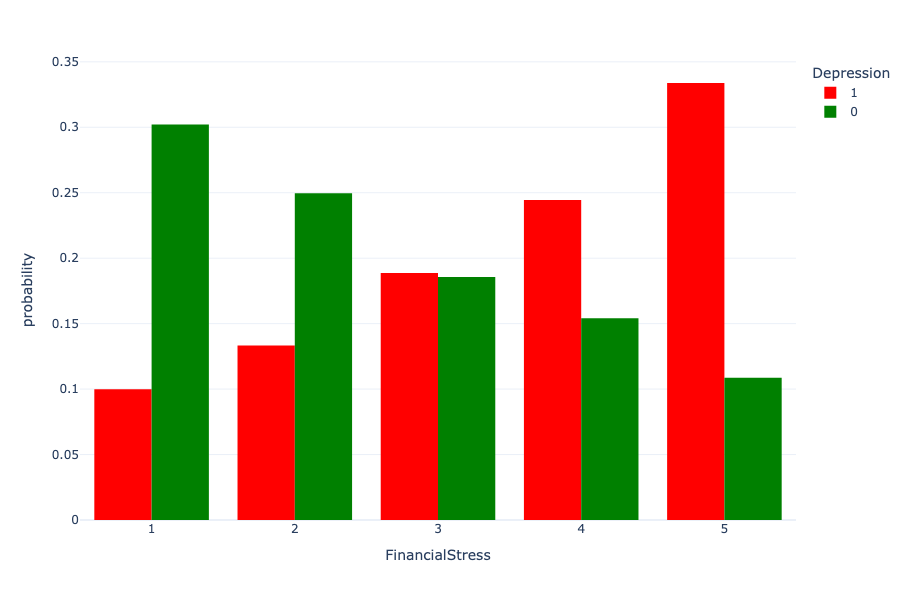

In [11]:
px.histogram(prep_df, x="FinancialStress", color="Depression", 
             barmode="group", color_discrete_map={1: "red", 0: "green"},
             histnorm="probability", width=800, height=600)

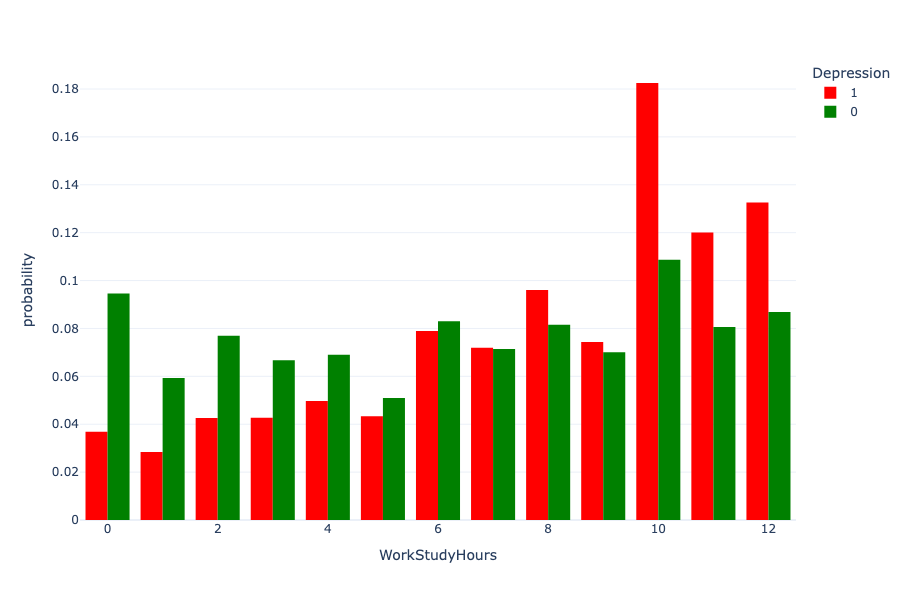

In [12]:
px.histogram(prep_df, x="WorkStudyHours", color="Depression", 
             barmode="group", color_discrete_map={1: "red", 0: "green"},
             histnorm="probability", width=800, height=600)

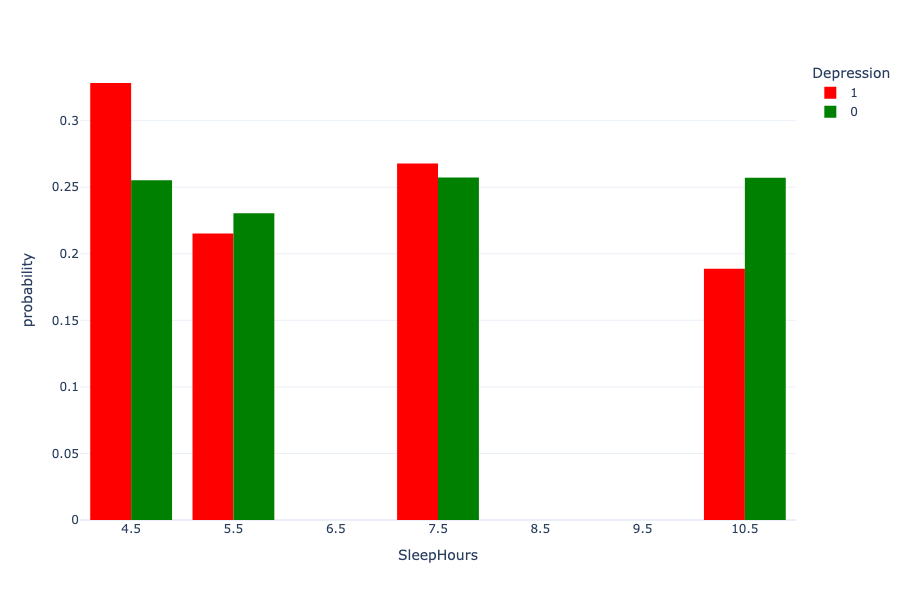

In [13]:
px.histogram(prep_df, x="SleepHours", color="Depression", 
             barmode="group", color_discrete_map={1: "red", 0: "green"},
             histnorm="probability", width=800, height=600)

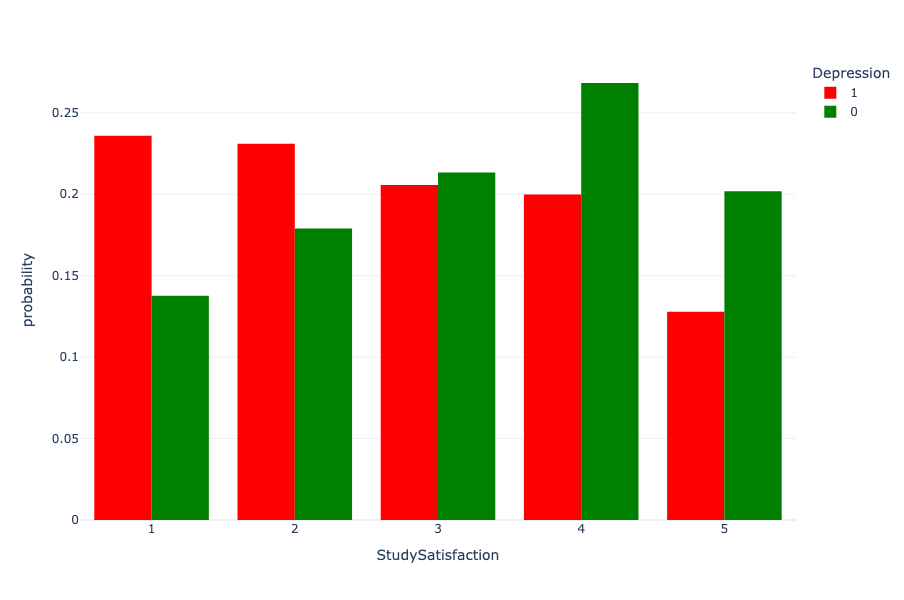

In [14]:
px.histogram(prep_df, x="StudySatisfaction", color="Depression", 
             barmode="group", color_discrete_map={1: "red", 0: "green"},
             histnorm="probability", width=800, height=600)

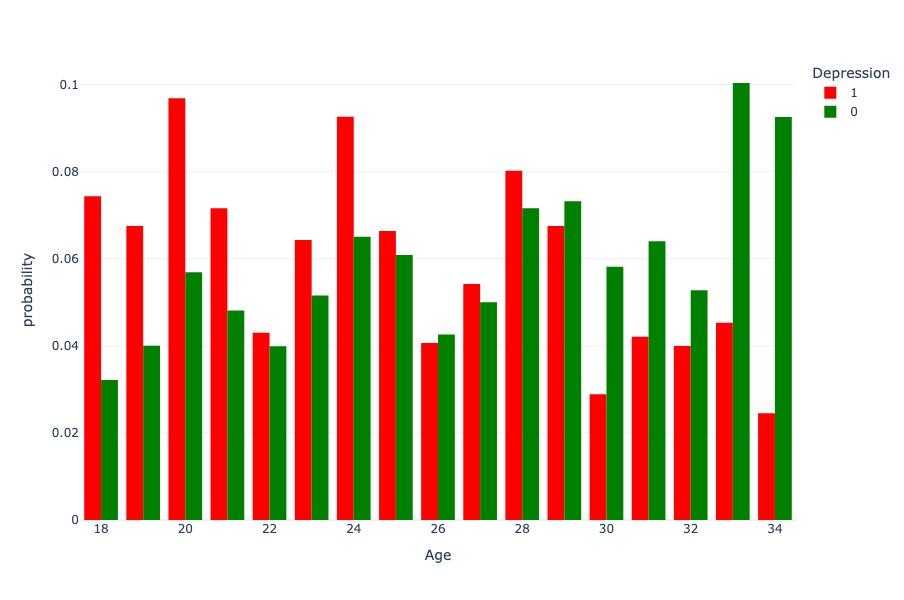

In [15]:
px.histogram(prep_df, x="Age", color="Depression", 
             barmode="group", color_discrete_map={1: "red", 0: "green"},
             histnorm="probability", width=800, height=600)

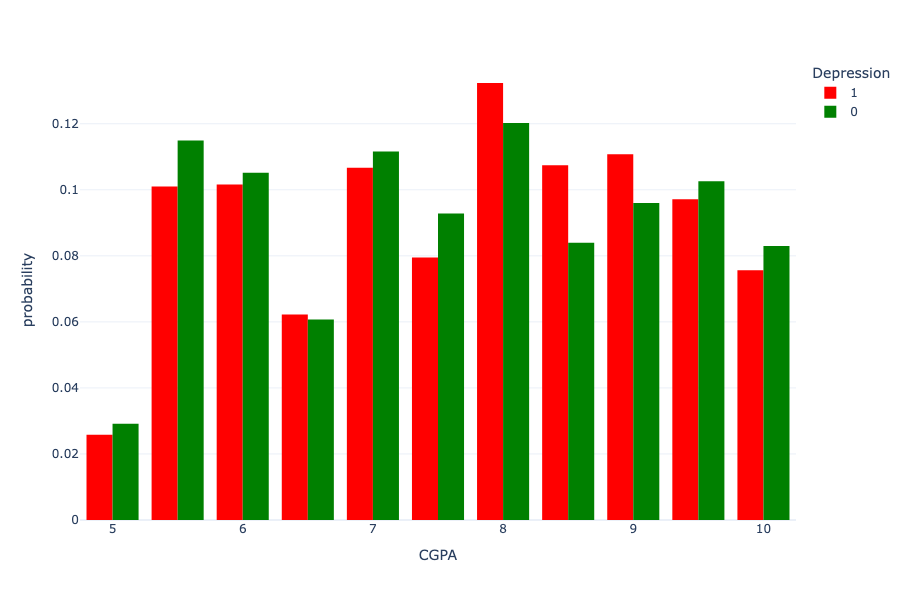

In [16]:
px.histogram(prep_df, x="CGPA", color="Depression", nbins=20,
             barmode="group", color_discrete_map={1: "red", 0: "green"},
             histnorm="probability", width=800, height=600)

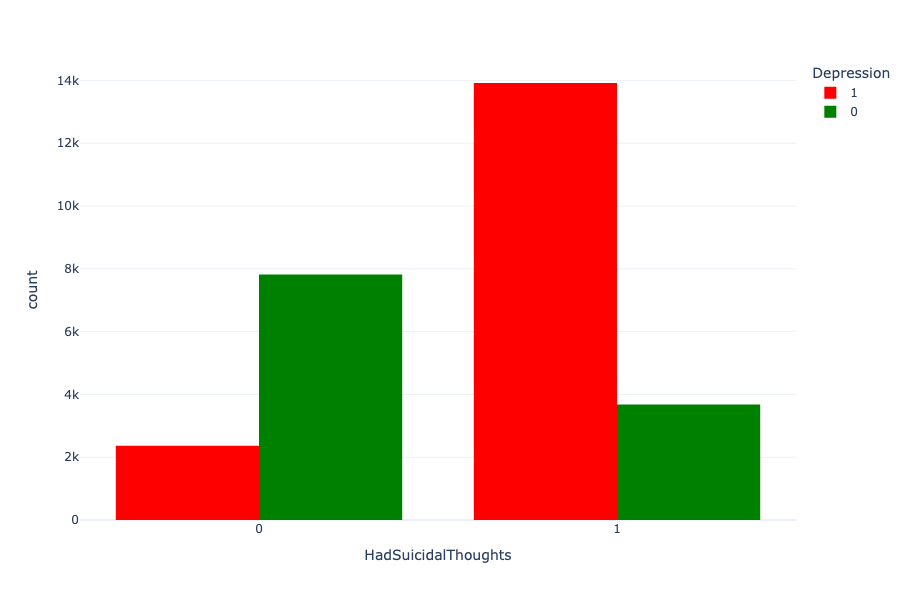

In [115]:
px.histogram(
    prep_df, x="HadSuicidalThoughts", 
    color="Depression",
    color_discrete_map={1: "red", 0: "green"},
    barmode="group",
    height=600
)

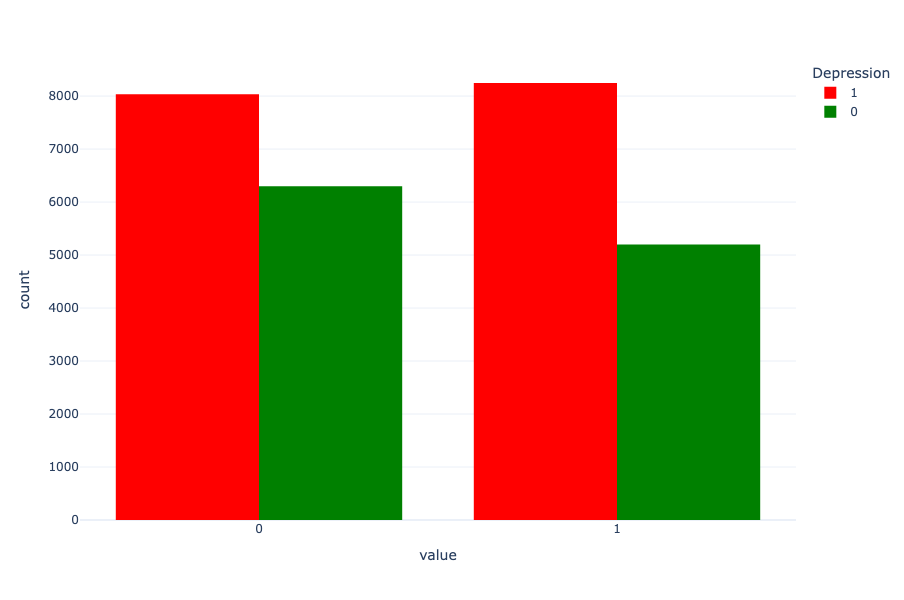

In [31]:
px.histogram(
    prep_df, 
    x=["FamilyHistoryofMentalIllness"], 
    color="Depression",
    color_discrete_map={1: "red", 0: "green"},
    barmode="group",
    height=600
)